In [1]:
import os
import pypsa
import pycountry
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from unit_helpers import (
    tj_to_twh,
    bcm_to_twh,
)

from data_preparing import (
    plot_total_gas_supply,
    add_shared_row_title,
    basic_axis_formatting,
    plot_stacked_bars,
    get_model_pipeline_imports,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    industry_demands,
    rescom_demands,
    plot_country_consumption,
)

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [2]:
path = Path.cwd().parent / 'resources'
regions = gpd.read_file(path / 'regions_onshore_base_s_50.geojson')
path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc')

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401
INFO:pypsa.io:Imported network base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [3]:
from gas_validation_data import (
    df_2024_residential,
    df_2024_industrial,
    df_2024_production,
    df_pipeline_imports,
    df_total_supply,
    df_storage_2024,
)

df_2024_residential = bcm_to_twh(df_2024_residential)
df_2024_industrial = bcm_to_twh(df_2024_industrial)
df_2024_production = bcm_to_twh(df_2024_production)
df_pipeline_imports = bcm_to_twh(df_pipeline_imports)
df_total_supply = bcm_to_twh(df_total_supply)
df_storage_2024 = bcm_to_twh(df_storage_2024)

ccon = pd.read_csv(
    'nrg_cb_gas$defaultview_linear_2_0.csv'
)
ccon = (
    ccon.loc[ccon['TIME_PERIOD'] == 2024]
    .set_index('Geopolitical entity (reporting)')
    ['OBS_VALUE']
    .rename('gas_demand')
    .apply(tj_to_twh)
)

def country_name_to_iso2(name):
    name = name.strip()
    try:
        return pycountry.countries.lookup(name).alpha_2
    except LookupError:
        return None

ccon = ccon.copy()
ccon.index = ccon.index.map(country_name_to_iso2)
ccon = ccon[~ccon.index.isnull()]
ccon = ccon.sort_values(ascending=False)

In [4]:
gens = n.generators.index[n.generators.carrier == 'gas']

In [5]:
n.statistics

yet to implement other pipeline representation in model!


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

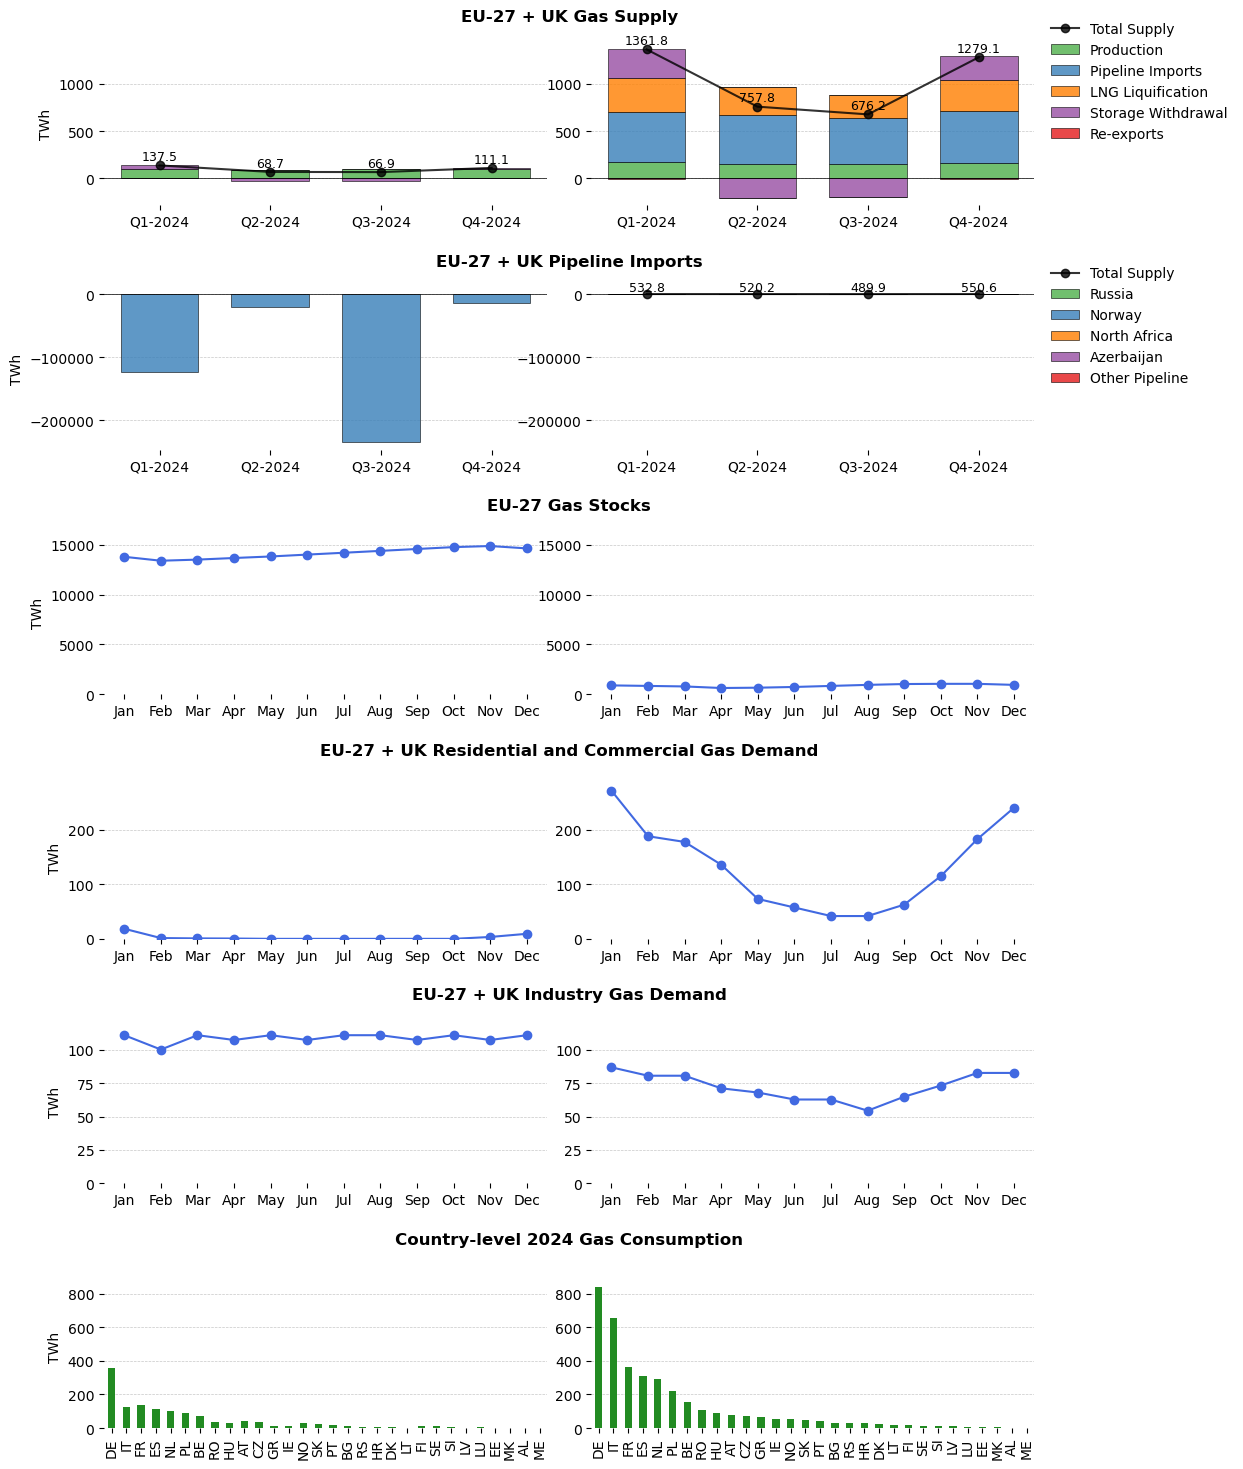

In [6]:

fig_height = 3 * 6  # 3 inches per row
fig_width = 12      # 2*2*3 = 12 inches for 2:1 aspect per ax, 2 axes per row
fig, axes = plt.subplots(
    nrows=6,
    ncols=2,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace':0.1, 'hspace':0.5}
    )

row_fns = [
    plot_total_gas_supply,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    plot_country_consumption,
]

right_data_list = [
    df_total_supply,
    df_pipeline_imports,
    df_storage_2024,
    df_2024_residential,
    df_2024_industrial,
    ccon,
]

for i in range(6):
    model_ax = axes[i, 0]
    true_ax = axes[i, 1]
    row_fns[i](model_ax, true_ax, n, right_data_list[i], fig, i)

    model_ax.set_xlabel("")
    model_ax.set_ylabel("")
    true_ax.set_xlabel("")
    true_ax.set_ylabel("")

    fig.canvas.draw()  # Needed to ensure positions are up to date
    bbox1 = model_ax.get_position()
    bbox2 = true_ax.get_position()

    x0 = bbox1.x1 - 0.02 * (bbox2.x0 - bbox1.x1)  # slight overlap
    width = bbox2.x0 - bbox1.x1 + 0.04 * (bbox2.x0 - bbox1.x1)
    y0 = bbox1.y0
    height = bbox1.height

    bbox_top = model_ax.get_position()
    bbox_bottom = model_ax.get_position()
    y0 = bbox_bottom.y0
    height = (bbox_top.y1 - bbox_bottom.y0) / 5

    '''
    rect = patches.FancyBboxPatch(
        (x0, y0), width, height,
        boxstyle="round,pad=0.02",
        linewidth=1, edgecolor='gray', facecolor='white', alpha=0.95,
        transform=fig.transFigure, zorder=10
    )

    fig.patches.append(rect)

    fig.text(
        x0 + width/2, y0 + height/2,
        f"Legend/Explanation\nPlaceholder\n(Row {i+1})",
        ha='center', va='center', fontsize=10, color='black', zorder=11
    )
    '''

for ax in axes[:,0]:
    ax.set_ylabel('TWh')

plt.savefig('validation_starting_point.pdf', bbox_inches='tight')
plt.show()

In [9]:
ss = n.statistics.energy_balance(groupby=['carrier', 'bus'])

ss.loc[
    (ss.index.get_level_values(2).str.contains('gas')) &
    (ss.index.get_level_values(2).str.contains('NO')) &
    (ss.index.get_level_values(1) == 'gas pipeline')
]

component  carrier       bus      
Link       gas pipeline  NO1 0 gas    390375.49456
dtype: float64

In [10]:
pipes = n.links.index[n.links.carrier == 'gas pipeline']

In [11]:
n.buses.carrier.unique()

array(['AC', 'lignite', 'coal', 'oil', 'oil primary', 'uranium', 'none',
       'co2', 'co2 stored', 'co2 sequestered', 'gas', 'H2', 'battery',
       'EV battery', 'land transport oil', 'urban central heat', 'biogas',
       'solid biomass', 'unsustainable bioliquids', 'NH3', 'methanol',
       'solid biomass for industry', 'gas for industry',
       'industry methanol', 'naphtha for industry', 'non-sequestered HVC',
       'process emissions', 'coal for industry', 'shipping oil',
       'kerosene for aviation', 'agriculture machinery oil',
       'low voltage', 'home battery', 'rural heat',
       'urban decentral heat'], dtype=object)

In [12]:
idx = pd.IndexSlice
n.statistics.energy_balance(groupby=['carrier']).loc[idx['Load', :]].sort_values()

carrier
residential urban decentral heat    -1.217715e+09
gas for industry                    -1.175320e+09
industry electricity                -1.070670e+09
naphtha for industry                -8.961300e+08
kerosene for aviation               -7.439070e+08
shipping oil                        -5.784152e+08
land transport oil                  -5.085732e+08
coal for industry                   -4.987831e+08
residential rural heat              -4.291998e+08
solid biomass for industry          -3.672000e+08
urban central heat                  -2.873205e+08
agriculture heat                    -2.148117e+08
low-temperature heat for industry   -1.856000e+08
NH3                                 -8.730000e+07
agriculture machinery oil           -5.142382e+07
agriculture electricity             -3.752588e+07
agriculture machinery electric      -2.203878e+07
land transport EV                   -1.116298e+07
industry methanol                   -8.740000e+06
H2 for industry                      8.790

In [13]:
eb = n.statistics.energy_balance(groupby=['carrier', 'bus'])
eb = eb.loc[eb.index.get_level_values(2).str.contains('urban decentral heat')]
eb = eb.groupby(level=[0,1]).sum()

In [14]:
eb.sort_values()

component  carrier                                   
Generator  services urban decentral heat vent           -2.233284e+09
Load       residential urban decentral heat             -1.217715e+09
           low-temperature heat for industry            -2.000000e+04
Link       residential urban decentral biomass boiler    7.590800e+02
           urban decentral oil boiler                    9.092731e+05
           residential urban decentral gas boiler        6.334360e+07
           urban decentral resistive heater              1.572556e+09
           residential urban decentral air heat pump     1.814209e+09
dtype: float64

In [15]:
oc = n.statistics.optimal_capacity(groupby=['carrier', 'bus'])
oc = oc.loc[oc.index.get_level_values(2).str.contains('urban decentral heat')]
oc = oc.groupby(level=[0,1]).sum()
oc.sort_values()

component  carrier                           
Generator  services urban decentral heat vent    418994.77879
dtype: float64

In [16]:
ic = n.statistics.optimal_capacity(groupby=['carrier', 'bus'])
ic = ic.loc[ic.index.get_level_values(2).str.contains('urban decentral heat')]
ic = ic.groupby(level=[0,1]).sum()
ic.sort_values()

component  carrier                           
Generator  services urban decentral heat vent    418994.77879
dtype: float64

In [17]:
n.links.loc[n.links.carrier == 'services urban decentral resistive heater']

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,location,under_construction,dc,tags,project_status,length_original,underground,geometry,reversed,voltage
Link,,,,,,,,,,,,,,,,,,,,,


In [18]:
heat_demands = pd.Index(n.statistics.energy_balance().index.get_level_values(2).unique())
heat_demands = heat_demands[heat_demands.str.contains('heat')]
heat_demands

Index(['residential rural heat', 'residential urban decentral heat',
       'urban central heat'],
      dtype='object', name='bus_carrier')

In [19]:
eb = n.statistics.energy_balance()
eb

component  carrier                           bus_carrier                     
Store      Battery Storage                   Battery Storage                     1.038000e-02
           EV battery                        EV battery                          1.346500e-01
           co2                               co2                                -4.339250e+08
           home battery                      home battery                        8.870000e-03
           non-sequestered HVC               non-sequestered HVC                 8.071763e+08
                                                                                     ...     
Load       residential rural heat            residential rural heat             -4.291998e+08
           residential urban decentral heat  residential urban decentral heat   -1.217715e+09
           shipping oil                      shipping oil                       -5.784152e+08
           solid biomass for industry        solid biomass for industry     

In [20]:
heat_demands

Index(['residential rural heat', 'residential urban decentral heat',
       'urban central heat'],
      dtype='object', name='bus_carrier')

residential rural heat
===============-----------------------------
residential rural heat
Index(['agriculture heat', 'residential rural biomass boiler',
       'residential rural heat', 'residential rural heat vent',
       'rural oil boiler', 'rural resistive heater',
       'services rural air heat pump', 'services rural gas boiler',
       'services rural ground heat pump'],
      dtype='object', name='carrier')
residential urban decentral heat
===============-----------------------------
residential urban decentral heat
Index(['low-temperature heat for industry',
       'residential urban decentral air heat pump',
       'residential urban decentral biomass boiler',
       'residential urban decentral gas boiler',
       'residential urban decentral heat',
       'services urban decentral heat vent', 'urban decentral oil boiler',
       'urban decentral resistive heater'],
      dtype='object', name='carrier')
urban central heat
===============-----------------------------
urban c

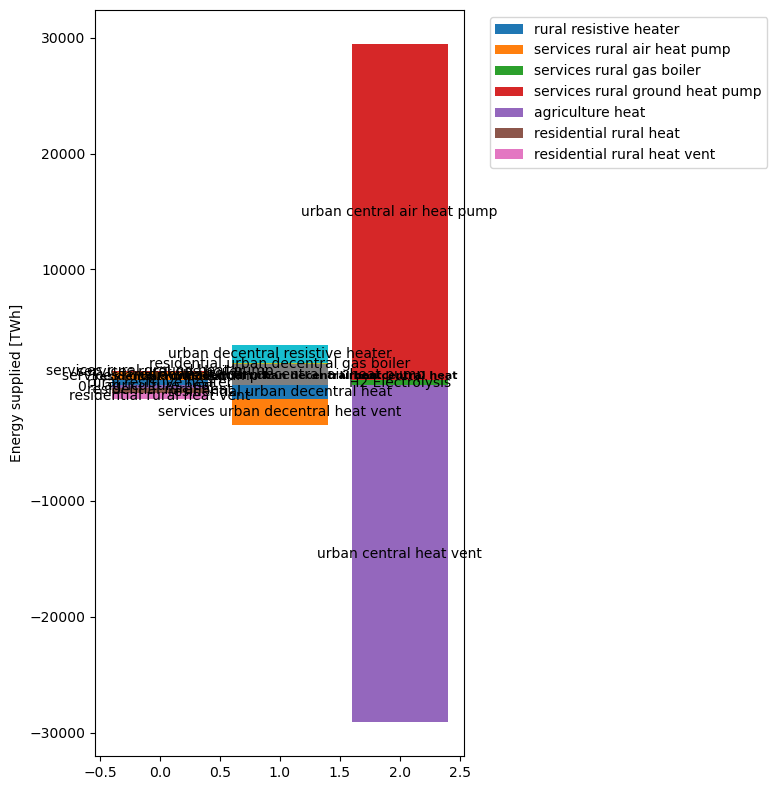

In [21]:
idx = pd.IndexSlice
fig, ax = plt.subplots(figsize=(8, 8))

for i, heat_demand in enumerate(heat_demands):

    print(heat_demand)

    try:
        ss = eb.loc[idx[: ,: ,heat_demand]]
    except KeyError:
        continue

    total = ss.clip(lower=0).sum()
    ss = ss.groupby(level=1).sum()
    print('===============-----------------------------')
    print(heat_demand)
    print(ss.index)
    ss = ss.loc[ss.abs() > 0.01 * total].mul(1e-6)

    # Split into positive and negative parts
    ss_pos = ss[ss > 0]
    ss_neg = ss[ss < 0]

    # Plot positive stack
    bottoms_pos = 0
    for j, (idx_val, val) in enumerate(ss_pos.items()):
        bar = ax.bar(
            i, val, bottom=bottoms_pos, label=idx_val if i == 0 else "", width=0.8, color=None
        )
        ax.text(
            i, bottoms_pos + val / 2,
            str(idx_val),
            ha='center', va='center', fontsize=10, color='k'
        )
        bottoms_pos += val

    # Plot negative stack
    bottoms_neg = 0
    for j, (idx_val, val) in enumerate(ss_neg.items()):
        bar = ax.bar(
            i, val, bottom=bottoms_neg, label=idx_val if i == 0 else "", width=0.8, color=None
        )
        ax.text(
            i, bottoms_neg + val / 2,
            str(idx_val),
            ha='center', va='center', fontsize=10, color='k'
        )
        bottoms_neg += val

    # Optionally, add text above the stack stating heat_demand
    ax.text(
        i, 300 + i * 50,
        heat_demand,
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

ax.set_ylabel('Energy supplied [TWh]')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
n.statistics.energy_balance().loc[idx[:,'AC',:]]

component  bus_carrier
Line       AC            -2.639903e+08
dtype: float64

In [23]:
n.global_constraints

,type,investment_period,carrier_attribute,sense,constant,mu
GlobalConstraint,,,,,,
lv_limit,transmission_volume_expansion_limit,NaN,"AC, DC",<=,1.916385e+08,0.000000
biomass limit,operational_limit,NaN,solid biomass,<=,1.360995e+07,-8.599747
unsustainable biomass limit,operational_limit,NaN,unsustainable solid biomass,==,1.206563e+09,0.291935
CO2Limit,co2_atmosphere,NaN,co2_emissions,<=,4.143526e+09,-0.000006
co2_sequestration_limit,operational_limit,NaN,co2 sequestered,>=,-0.000000e+00,0.000000


In [36]:
carrier_mp = []

for carrier in n.buses.carrier.unique():
    buses = n.buses.index[n.buses.carrier == carrier]

    carrier_mp.append(n.buses_t.marginal_price[buses].mean().mean())

carrier_mp = pd.Series(carrier_mp, index=n.buses.carrier.unique())

In [37]:
carrier_mp.sort_values()

EV battery                      -35.122474
low voltage                     -31.610995
home battery                    -30.939305
AC                              -26.662285
battery                         -26.101869
biogas                           -4.518680
H2                               -1.373519
co2 sequestered                  -0.036038
non-sequestered HVC              -0.007302
none                              0.000000
co2                               0.010433
urban central heat                0.097426
lignite                           3.231500
urban decentral heat              5.294765
rural heat                        6.270359
coal                              9.565092
coal for industry                 9.572115
solid biomass for industry       10.035941
NH3                              11.751471
gas for industry                 19.253556
methanol                         22.098966
industry methanol                22.106673
solid biomass                    22.557211
gas        

In [ ]:
n.stores.loc[n.stores.bus == 'EU uranium']

,bus,type,carrier,e_nom,e_nom_mod,e_nom_extendable,e_nom_min,e_nom_max,e_min_pu,e_max_pu,...,marginal_cost,marginal_cost_quadratic,marginal_cost_storage,capital_cost,standing_loss,active,build_year,lifetime,e_nom_opt,location
Store,,,,,,,,,,,,,,,,,,,,,
EU uranium Store,EU uranium,,uranium,0.0,0.0,True,0.0,inf,0.0,1.0,...,0.010103,0.0,0.0,0.1,0.0,True,0,inf,64.62891,


In [31]:
n.links.loc[n.links.bus0 == 'EU uranium']

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,location,under_construction,dc,tags,project_status,length_original,underground,geometry,reversed,voltage
Link,,,,,,,,,,,,,,,,,,,,,
FR0 3 nuclear-1965,EU uranium,FR0 3,,nuclear,0.326,True,1965,64.0,11104.294479,0.0,...,,NaN,NaN,,,NaN,NaN,,False,NaN
GB2 1 nuclear-1965,EU uranium,GB2 1,,nuclear,0.326,True,1965,87.0,16208.588957,0.0,...,,NaN,NaN,,,NaN,NaN,,False,NaN
CH0 0 nuclear-1970,EU uranium,CH0 0,,nuclear,0.326,True,1970,82.0,2239.263804,0.0,...,,NaN,NaN,,,NaN,NaN,,False,NaN
FR0 4 nuclear-1970,EU uranium,FR0 4,,nuclear,0.326,True,1970,70.0,9202.453988,0.0,...,,NaN,NaN,,,NaN,NaN,,False,NaN
GB2 1 nuclear-1970,EU uranium,GB2 1,,nuclear,0.326,True,1970,66.0,4049.079755,0.0,...,,NaN,NaN,,,NaN,NaN,,False,NaN
BE0 0 nuclear-1975,EU uranium,BE0 0,,nuclear,0.326,True,1975,51.0,18156.441718,0.0,...,,NaN,NaN,,,NaN,NaN,,False,NaN
BG0 0 nuclear-1975,EU uranium,BG0 0,,nuclear,0.326,True,1975,77.0,6380.368098,0.0,...,,NaN,NaN,,,NaN,NaN,,False,NaN
ES6 0 nuclear-1975,EU uranium,ES6 0,,nuclear,0.326,True,1975,60.0,3206.441718,0.0,...,,NaN,NaN,,,NaN,NaN,,False,NaN
FR0 1 nuclear-1975,EU uranium,FR0 1,,nuclear,0.326,True,1975,56.0,10981.595092,0.0,...,,NaN,NaN,,,NaN,NaN,,False,NaN


In [25]:
n.buses.loc[['co2 atmosphere']].T

Bus,co2 atmosphere
v_nom,1.0
type,
x,-5.5
y,46.0
carrier,co2
unit,t_co2
v_mag_pu_set,1.0
v_mag_pu_min,0.0
v_mag_pu_max,inf
control,PQ


In [101]:
n.links.carrier.unique()

array(['DC', 'oil refining', 'co2 sequestered', 'OCGT', 'CCGT',
       'H2 Electrolysis', 'gas pipeline', 'gas pipeline new',
       'battery charger', 'battery discharger', 'Sabatier', 'SMR CC',
       'SMR', 'BEV charger', 'V2G', 'land transport oil',
       'urban central air heat pump', 'urban central gas boiler',
       'urban central gas CHP', 'urban central gas CHP CC',
       'unsustainable bioliquids', 'biogas to gas',
       'urban central solid biomass CHP',
       'urban central solid biomass CHP CC', 'biomass to liquid',
       'electrobiofuels', 'Haber-Bosch', 'ammonia cracker',
       'biomass-to-methanol', 'OCGT methanol',
       'solid biomass for industry', 'solid biomass for industry CC',
       'gas for industry', 'gas for industry CC', 'industry methanol',
       'methanolisation', 'Fischer-Tropsch', 'naphtha for industry',
       'HVC to air', 'process emissions', 'process emissions CC',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       '

In [102]:
h2 = n.links.index[n.links.carrier == 'H2 Electrolysis']
n.links_t.p0[h2].sum(axis=1) * 24 / 1e6

snapshot
2024-01-01    18.272803
2024-01-02    18.453008
2024-01-03    18.600337
2024-01-04    18.543521
2024-01-05    18.665761
                ...    
2024-12-27    18.633544
2024-12-28    18.277575
2024-12-29    17.972838
2024-12-30    18.613901
2024-12-31    18.511521
Length: 365, dtype: float64

In [103]:
n.links.loc[h2[0]].T

bus0                                          AL0 0
bus1                                       AL0 0 H2
type                                               
carrier                             H2 Electrolysis
efficiency                                   0.5874
active                                         True
build_year                                     2025
lifetime                                       25.0
p_nom                                           0.0
p_nom_mod                                       0.0
p_nom_extendable                               True
p_nom_min                                       0.0
p_nom_max                                       inf
p_set                                           0.0
p_min_pu                                        0.0
p_max_pu                                        1.0
capital_cost                          226458.930997
marginal_cost                              0.009429
marginal_cost_quadratic                         0.0
stand_by_cos

In [68]:
lv = n.links.index[n.links.carrier == 'electricity distribution grid']
n.links_t.p0[lv].sum(axis=1) * 24 / 1e6

snapshot
2024-01-01    18.772275
2024-01-02    19.693651
2024-01-03    20.533366
2024-01-04    20.249668
2024-01-05    20.600102
                ...    
2024-12-27    20.839178
2024-12-28    19.141402
2024-12-29    18.545933
2024-12-30    20.894679
2024-12-31    20.863250
Length: 365, dtype: float64

In [64]:
n.links.index[n.links.carrier == 'distribution grid']

Index([], dtype='object', name='Link')

In [ ]:
elec = n.links.index

In [ ]:
vents = n.generators.index[n.generators.carrier == 'urban central heat vent']

n.generators_t.p[vents].sum(axis=1) * 24 / 1e6

snapshot
2024-01-01   -58.678117
2024-01-02   -80.680415
2024-01-03   -80.807445
2024-01-04   -82.755227
2024-01-05   -81.700878
                ...    
2024-12-27   -77.242203
2024-12-28   -55.165464
2024-12-29   -55.026387
2024-12-30   -75.815567
2024-12-31   -75.258184
Length: 365, dtype: float64

In [49]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [ ]:
c = 'urban central air heat pump'
l = n.links.index[n.links.carrier == c]

n.links.loc[[l[0]]].T

Link,AL0 0 urban central air heat pump-2025
bus0,AL0 0 low voltage
bus1,AL0 0 urban central heat
type,
carrier,urban central air heat pump
efficiency,1.0
active,True
build_year,2025
lifetime,25.0
p_nom,0.0
p_nom_mod,0.0


In [ ]:
lv = n.buses.index[n.buses.carrier == 'AC']
n.buses_t.marginal_price[lv].mean(axis=1).sort_values()

snapshot
2024-01-08   -3410.738838
2024-01-09   -2573.009720
2024-01-10   -1952.046115
2024-08-12    -526.152723
2024-07-18    -248.084763
                 ...     
2024-12-14      -0.025251
2024-01-20      -0.025135
2024-01-14      -0.025002
2024-01-13      -0.024744
2024-01-21      -0.024422
Length: 365, dtype: float64

In [35]:
n.links.groupby('carrier')['p_nom_extendable'].max().tail(34)

carrier
home battery charger                   True
home battery discharger                True
industry methanol                      True
kerosene for aviation                  True
land transport oil                     True
lignite                               False
methanolisation                        True
naphtha for industry                   True
nuclear                               False
oil                                   False
oil refining                          False
process emissions                      True
process emissions CC                   True
rural air heat pump                    True
rural biomass boiler                   True
rural gas boiler                       True
rural ground heat pump                 True
rural oil boiler                      False
rural resistive heater                False
shipping oil                           True
solid biomass for industry             True
solid biomass for industry CC          True
unsustainable bioliquids

In [37]:
n.stores.carrier.unique()

array(['lignite', 'coal', 'oil', 'uranium', 'co2', 'co2 stored',
       'co2 sequestered', 'gas', 'H2 Store', 'battery', 'EV battery',
       'ammonia store', 'methanol', 'non-sequestered HVC', 'home battery'],
      dtype=object)

In [42]:
s = n.stores.index[n.stores.carrier == 'co2 stored']

<Axes: xlabel='snapshot'>

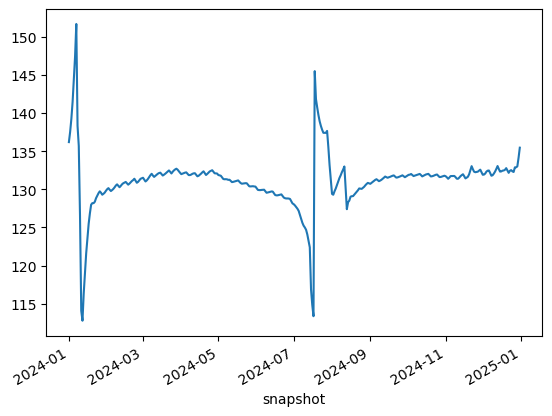

In [45]:
#n.stores_t.e['co2 atmosphere'].plot()
n.stores_t.e[s].sum(axis=1).plot()